In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("customer_shopping_behavior_dataset.csv")

In [4]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
# df.describe() .....only gives summary statistics of numerical columns
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [7]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [8]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))


# Initially I found few missing values in 'Review Rating' column and then I used groupby('category') to split the category into diff buckets/categories
# of 'Category' col and then apply the median of respective buckets/categories to the missing values 'Review Rating' col. 
# - Median is better than mean in this case as mean can be influenced by outliers hence will skew the data. 
# - Taking median of the entire column isn't ideal as different categories can have different values, hence the missing values should have median only 
#   of the category it belongs. Therefore I used groupby('Category'). Doing so eliminates the bias in the data. 


In [9]:
# Almost all the column names have spaces between them and letter casing is not consistent. 

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')
df = df.rename(columns={'purchase_amount_(usd)': 'purchase_amount'})

In [10]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

## Feature Engineering ##

In [11]:
# 1) Creating a new column: age_group

# This division/feature engg is useful for marketing or understanding customer behavior.
groups = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']         # To group customers in 4 diff age groups
df['age_group'] = pd.qcut(df['age'], q=4, labels = groups)

# I have divided the the 'age' column into 4 different categories (groups) using "qcut". 

In [12]:
df[['age', 'age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [13]:
# 2) Creating new column: purchase_frequency_days

# The current dataset has frequency of purchases (weekly, annually, etc...) col that is in text form. For analysis text form is harder than numerical form.
# I have mapped the 'freq_of_purchases' col with the freq_mapping dict to create a new col which represents the fre_of_purchases col in numbers rather than text.

frequency_mapping= {
    'Fortnightly': 14,
    'Weekly': 7,
    'Annually': 365,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Monthly': 30,
    'Every 3 Months': 90}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)



In [14]:
df[['frequency_of_purchases', 'purchase_frequency_days']].head(10)

,frequency_of_purchases,purchase_frequency_days
0,Fortnightly,14
1,Fortnightly,14
2,Weekly,7
3,Weekly,7
4,Annually,365
5,Weekly,7
6,Quarterly,90
7,Weekly,7
8,Annually,365
9,Quarterly,90


In [15]:
# 3) Check if discount_applied and promo_code_used are redundant. Evidently when a promo code is used, a discount is applied hence both indicate 'yes'. 
#    But a company can still give discounts without the use of any promo code such as seasonal discounts, clearance discounts, etc. Hence, I'm trying to 
#    see if these 2 columns differ in any instance. Basically trying to find if promo_code=No and discount_applied=Yes, then both columns are needed. If 
#    if both the columns are same throughout, then they are reducndant and I will then eliminate a column.

df[['discount_applied', 'promo_code_used']].head(10)
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [16]:
# Since the result came out to be 'True', they are redundant and we don't need both columns. We can eliminate 1 col.

df = df.drop('promo_code_used', axis=1)

## Now let's push the data into PostgreSQL database for deeper analysis and Business Insights ##

In [53]:
!pip install psycopg2-binary sqlalchemy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ------------------- -------------------- 1.3/2.7 MB 13.4 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 12.1 MB/s  0:00:00


In [56]:
# Connect the notebook to PostgreSQL

from sqlalchemy import create_engine

username = 'postgres'     # Default
password = 'postgres'     # Set by me during postgres installation
host = 'localhost'        # if running locally
port = '5433'             # Default postgres port
database = 'customer_behavior'    # Created by me on postgres/pg-admin

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Next load the dataframe into postgres
table_name = 'customer'    # Any  name of your choice
df.to_sql(table_name, engine, if_exists = "replace", index = False)

print(f"Data successfully loaded into the table '{table_name}' in your database - {database}")

Data successfully loaded into the table 'customer' in your database - customer_behavior


## Analyses

Three focused analyses:
1. **Revenue concentration** across top spender tiers
2. **Product-level sales dependency on discounts**
3. **Subscriber vs. non-subscriber discount reliance**


### 1. Revenue concentration across top spender tiers

In [21]:
# Cumulative revenue share by sorted customer spend (Pareto-style view)
amt = df['purchase_amount'].sort_values(ascending=False).reset_index(drop=True)
total = amt.sum()
cum_share = amt.cumsum() / total * 100
cust_share = (amt.index + 1) / len(amt) * 100

for pct in [10, 20, 30, 50]:
    k = int(len(amt) * pct / 100)
    print(f"Top {pct:>2}% of customers -> {amt.head(k).sum()/total*100:5.1f}% of revenue")


Top 10% of customers ->  16.1% of revenue
Top 20% of customers ->  31.0% of revenue
Top 30% of customers ->  44.5% of revenue
Top 50% of customers ->  67.2% of revenue


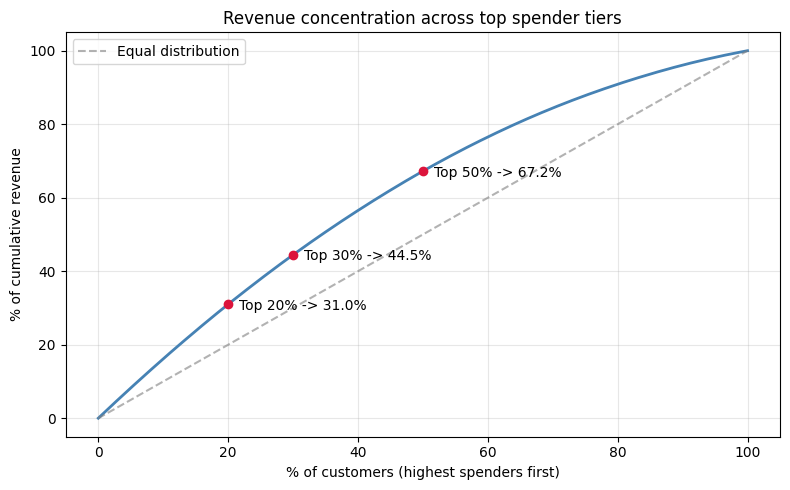

In [22]:
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(cust_share, cum_share, color='steelblue', linewidth=2)
ax.plot([0,100],[0,100], '--', color='gray', alpha=0.6, label='Equal distribution')
for pct in [20, 30, 50]:
    k = int(len(amt) * pct / 100)
    y = amt.head(k).sum()/total*100
    ax.scatter([pct],[y], color='crimson', zorder=5)
    ax.annotate(f'Top {pct}% -> {y:.1f}%', (pct, y), textcoords='offset points', xytext=(8,-4))
ax.set_xlabel('% of customers (highest spenders first)')
ax.set_ylabel('% of cumulative revenue')
ax.set_title('Revenue concentration across top spender tiers')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### 2. Product-level sales dependency on discounts

In [25]:
# Share of each product's sales that involved a discount
item_disc = (df.assign(is_disc=(df['discount_applied']=='Yes').astype(int))
               .groupby('item_purchased')['is_disc'].mean().mul(100)
               .sort_values(ascending=False))
print(item_disc.round(1))
print(f"Products with >40% discount-driven sales: {(item_disc>40).sum()} of {len(item_disc)}")


item_purchased
Hat           50.0
Sneakers      49.7
Coat          49.1
Sweater       48.2
Pants         47.4
Boots         46.5
Jeans         46.0
Dress         45.2
Hoodie        45.0
Backpack      44.8
Belt          44.7
Jewelry       44.4
Shorts        43.3
Gloves        42.9
Scarf         42.7
Shirt         42.0
T-shirt       41.5
Sunglasses    41.0
Shoes         40.7
Jacket        39.9
Handbag       39.9
Skirt         38.6
Sandals       36.9
Blouse        33.9
Socks         32.7
Name: is_disc, dtype: float64
Products with >40% discount-driven sales: 19 of 25


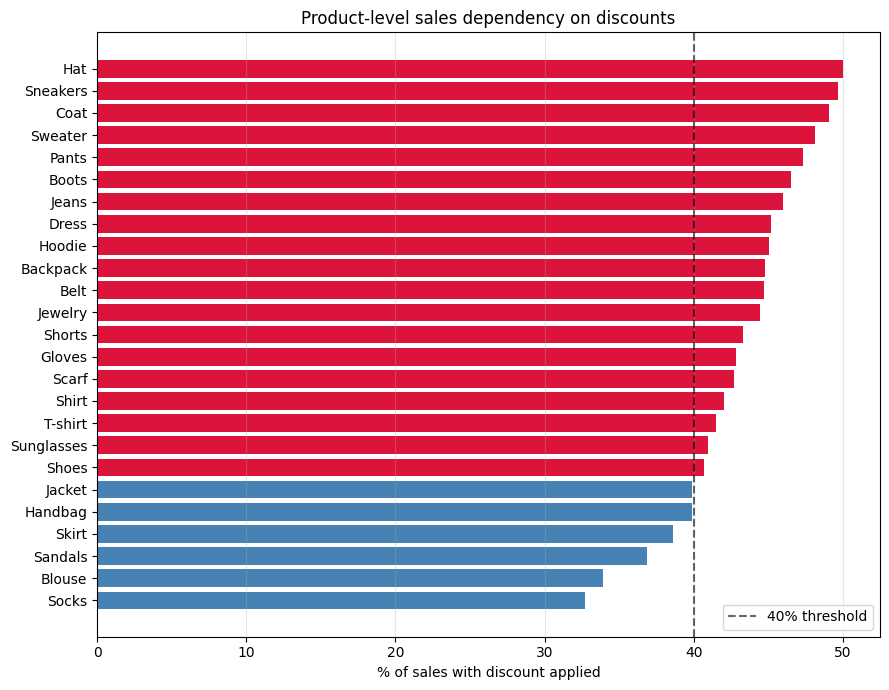

In [26]:
fig, ax = plt.subplots(figsize=(9,7))
colors = ['crimson' if v>40 else 'steelblue' for v in item_disc.values]
ax.barh(item_disc.index[::-1], item_disc.values[::-1], color=colors[::-1])
ax.axvline(40, color='black', linestyle='--', alpha=0.6, label='40% threshold')
ax.set_xlabel('% of sales with discount applied')
ax.set_title('Product-level sales dependency on discounts')
ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()


### 3. Subscriber vs. non-subscriber discount reliance

In [27]:
df.head(2)

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle-aged,14
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14


In [28]:
sub = (df.assign(is_disc=(df['discount_applied']=='Yes').astype(int))
         .groupby('subscription_status')
         .agg(customers=('customer_id','count'),
              avg_spend=('purchase_amount','mean'),
              total_revenue=('purchase_amount','sum'),
              discount_rate=('is_disc','mean')))
sub['discount_rate'] = sub['discount_rate']*100
print(sub.round(2))


                     customers  avg_spend  total_revenue  discount_rate
subscription_status                                                    
No                        2847      59.87         170436          21.92
Yes                       1053      59.49          62645         100.00


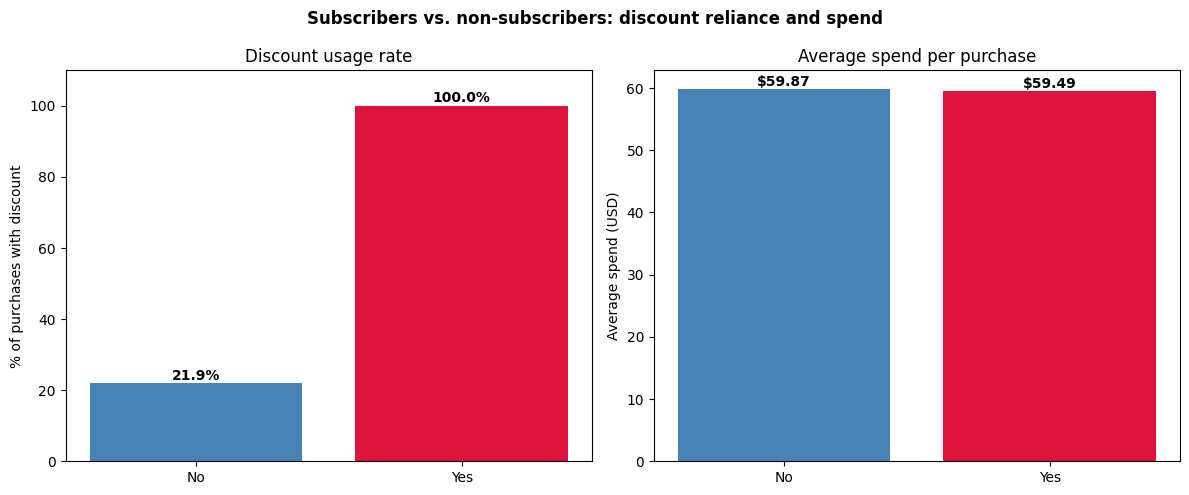

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].bar(sub.index, sub['discount_rate'], color=['steelblue','crimson'])
for i,v in enumerate(sub['discount_rate']):
    axes[0].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
axes[0].set_ylabel('% of purchases with discount')
axes[0].set_title('Discount usage rate')
axes[0].set_ylim(0, 110)

axes[1].bar(sub.index, sub['avg_spend'], color=['steelblue','crimson'])
for i,v in enumerate(sub['avg_spend']):
    axes[1].text(i, v+0.5, f'${v:.2f}', ha='center', fontweight='bold')
axes[1].set_ylabel('Average spend (USD)')
axes[1].set_title('Average spend per purchase')

fig.suptitle('Subscribers vs. non-subscribers: discount reliance and spend', fontweight='bold')
plt.tight_layout(); plt.show()
